In [1]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as dp
import os

In [2]:
# 파일 리스트
file_paths = [
    'AMD.csv', 'S&P500 ETF.csv', '나스닥 ETF.csv', '마이크로소프트.csv',
    '메타.csv', '아마존.csv', '알파벳.csv', '애플.csv', '엔비디아.csv', '테슬라.csv'
]

df_dict = {}
for path in file_paths:
    df = pd.read_csv(f'/home/nshawny/AI project 2/personal_data/stock/overseas/{path}')
    df['Name'] = os.path.splitext(path)[0]  # 종목명 저장
    df_dict[path] = df

In [3]:
for name, df in df_dict.items():
    df['High_Low_Range'] = (df['High'] - df['Low']) / df['Close']
    df['Volatility_20'] = df['Close'].rolling(window=20).std()

In [4]:
summary = []
for name, df in df_dict.items():
    mean_vol = df['High_Low_Range'].tail(252).mean()
    summary.append((name, mean_vol))

summary.sort(key=lambda x: x[1])
print(summary[:3])  # 변동성 낮은 종목 3개 추출


[('S&P500 ETF.csv', 0.012450165171429398), ('나스닥 ETF.csv', 0.016445229149056814), ('마이크로소프트.csv', 0.018592277294242853)]


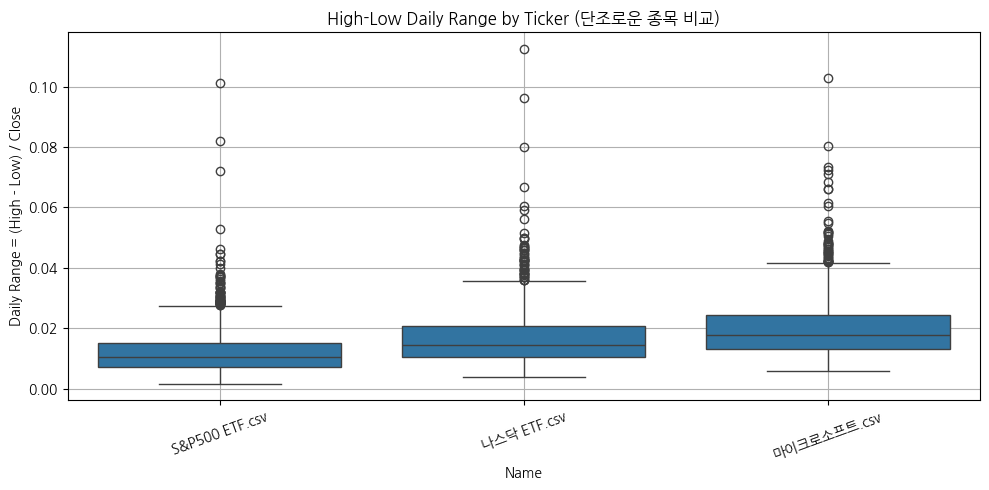

In [5]:
plt.rcParams['font.family'] = 'NanumGothic'
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# 3개 종목만 필터
selected_names = ['S&P500 ETF.csv', '나스닥 ETF.csv', '마이크로소프트.csv']

# 하나의 df로 통합
df_all = pd.concat([df_dict[name].assign(Name=name) for name in selected_names])

# 박스플롯
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x='Name', y='High_Low_Range')
plt.title("High-Low Daily Range by Ticker (단조로운 종목 비교)")
plt.ylabel("Daily Range = (High - Low) / Close")
plt.xticks(rotation=20)
plt.grid(True)
plt.tight_layout()
plt.show()


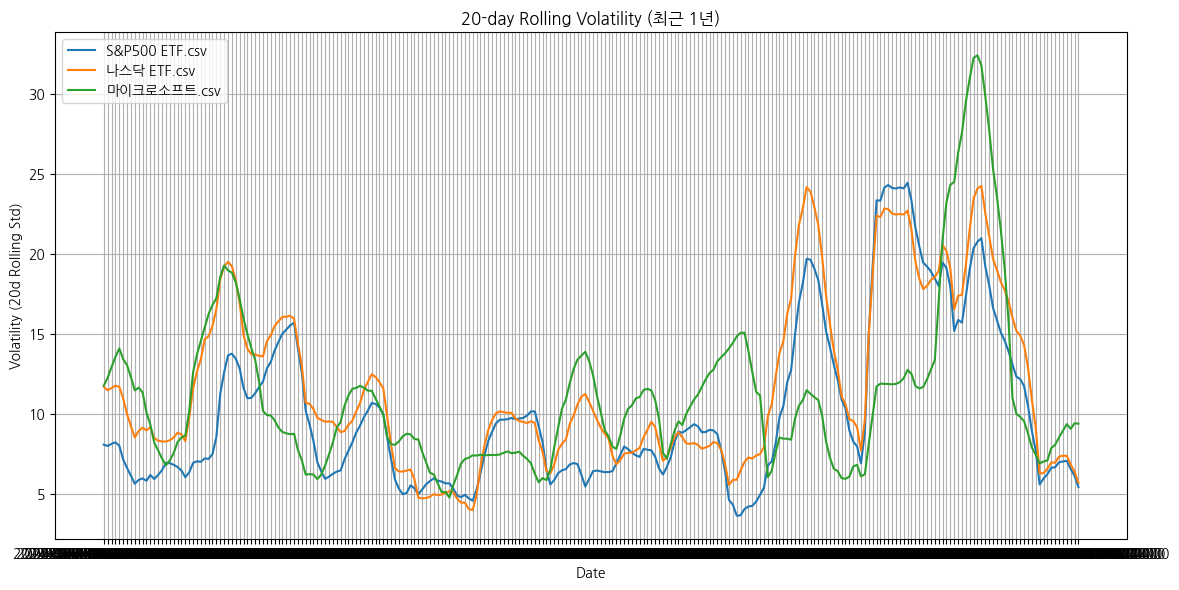

In [6]:
plt.figure(figsize=(12, 6))
for name in selected_names:
    df = df_dict[name]
    plt.plot(df['Date'][-252:], df['Volatility_20'][-252:], label=name)

plt.title("20-day Rolling Volatility (최근 1년)")
plt.xlabel("Date")
plt.ylabel("Volatility (20d Rolling Std)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
